In [7]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

In [8]:
data = simple_simulation()
print(data)

AnnData object with n_obs × n_vars = 5000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction'
    var: 'ambient_profile'
    uns: 'simulation_params', 'type_profiles'


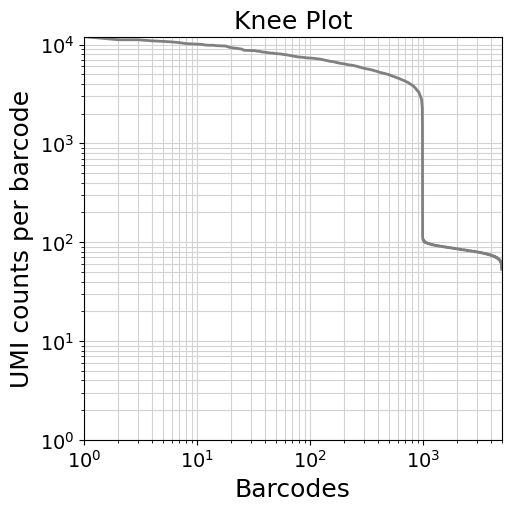

In [9]:
cm_utils.knee_plot(data)

In [10]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.03, cell_ambient_fraction=0.01, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path)

18:12:33 - INFO - Inferring gene ambient fractions.
18:12:33 - INFO - Added 'ambient_fraction' to adata.var.
18:12:33 - INFO - Inferring celltype profiles.
18:12:33 - INFO - Number of parameters in the cellmender model: 27,941 (alpha_i: 994, beta: 1, gamma_type: 8,946, p_k: 18,000)
18:12:33 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
18:12:33 - INFO - Performing Sparse EM with 1 Numba threads
18:12:33 - INFO - EM Iter   1: ll=-34517748.004 mean_alpha=0.034401 beta=0.011401
18:12:33 - INFO - EM Iter   2: ll=-40185242.039 mean_alpha=0.038974 beta=0.015399


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


18:12:34 - INFO - EM Iter   3: ll=-39914149.433 mean_alpha=0.039590 beta=0.015969
18:12:34 - INFO - EM Iter   4: ll=-39906486.357 mean_alpha=0.039780 beta=0.016094
18:12:34 - INFO - EM Iter   5: ll=-39905038.899 mean_alpha=0.039894 beta=0.016123
18:12:34 - INFO - EM Iter   6: ll=-39904509.045 mean_alpha=0.039996 beta=0.016126
18:12:34 - INFO - EM Iter   7: ll=-39904179.683 mean_alpha=0.040104 beta=0.016119
18:12:34 - INFO - EM Iter   8: ll=-39903900.076 mean_alpha=0.040221 beta=0.016108
18:12:34 - INFO - EM Iter   9: ll=-39903635.602 mean_alpha=0.040350 beta=0.016096
18:12:34 - INFO - EM Iter  10: ll=-39903378.201 mean_alpha=0.040489 beta=0.016083
18:12:34 - INFO - EM Iter  11: ll=-39903126.115 mean_alpha=0.040640 beta=0.016069
18:12:34 - INFO - EM Iter  12: ll=-39902879.115 mean_alpha=0.040801 beta=0.016055
18:12:34 - INFO - EM Iter  13: ll=-39902637.344 mean_alpha=0.040972 beta=0.016041
18:12:34 - INFO - EM Iter  14: ll=-39902401.022 mean_alpha=0.041153 beta=0.016027
18:12:34 - INFO 

In [ ]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [ ]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction  cell_ambient_fraction  \
cell_2          5   Type_5     False          0.007032                   0.01   
cell_3          6   Type_6     False          0.094343                   0.01   
cell_5          5   Type_5     False          0.041950                   0.01   
cell_19         7   Type_7     False          0.128143                   0.01   
cell_20         6   Type_6     False          0.099207                   0.01   
...           ...      ...       ...               ...                    ...   
cell_4969       2   Type_2     False          0.061252                   0.01   
cell_4974       3   Type_3     False          0.170702                   0.01   
cell_4991       2   Type_2     False          0.065687                   0.01   
cell_4992       4   Type_4     False          0.037516                   0.01   
cell_4997       5   Type_5     False          0.125038                   0.01   

           alpha_hat  z_hat

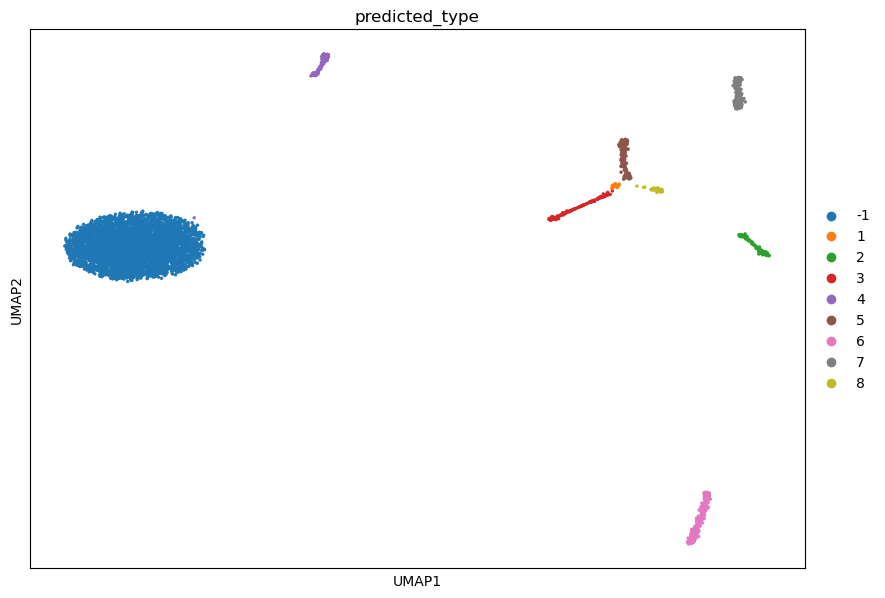

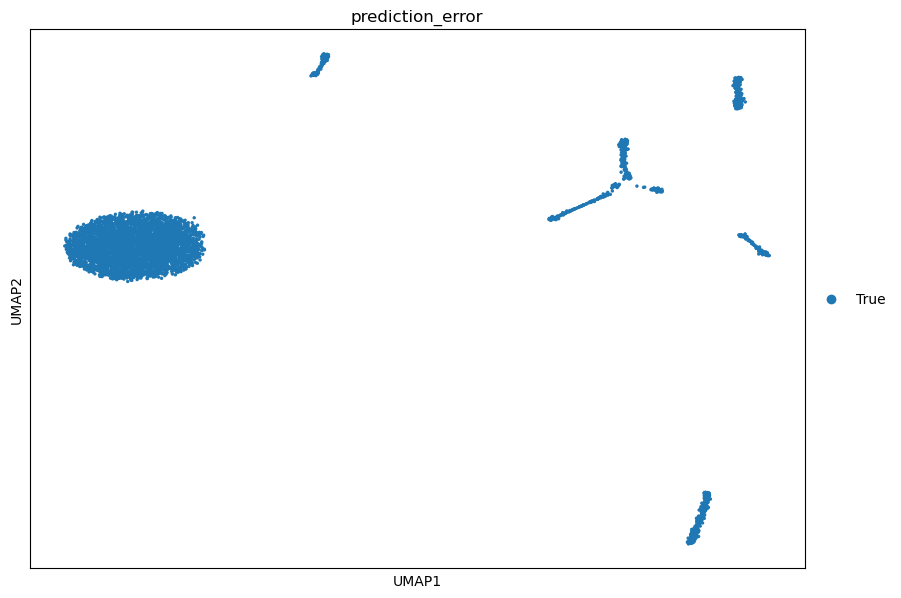

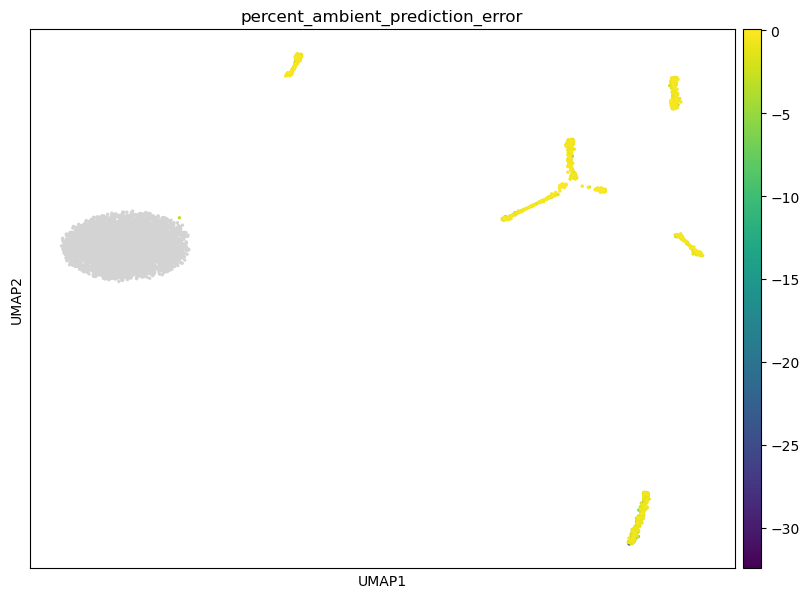

In [ ]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)